In [2]:
%load_ext autoreload
%autoreload 2

import os
import pandas as pd
from src.ingestion import DataIngestor

/usr/local/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
START_DATE = "2025-03-01"
END_DATE = "2025-12-31"

ingestor = DataIngestor(start_date=START_DATE, end_date=END_DATE, frequency="W")

In [4]:
df_market = ingestor.fetch_market_data(ticker="BTC-USD")

df_market.head()

[*********************100%***********************]  1 of 1 completed


Price,Open,High,Low,Close,Volume
timestamp,,,,,
2025-03-02,84373.867188,95043.437500,83794.234375,94248.351562,87588969488
2025-03-09,94248.421875,94429.750000,80052.484375,80601.039062,351467410238
2025-03-16,80597.148438,85263.289062,76624.250000,82579.687500,245099235090
2025-03-23,82576.335938,87443.265625,81179.992188,86054.375000,154637791297
2025-03-30,86070.929688,88758.726562,81573.250000,82334.523438,181637739548


In [5]:
df_mining = ingestor.fetch_mining_metrics()

df_mining.head()

,hash_rate,difficulty
timestamp,,
2025-03-09,7.777387e+08,1.105684e+14
2025-03-16,8.306723e+08,1.121495e+14
2025-03-23,7.916475e+08,1.121495e+14
2025-03-30,8.708571e+08,1.137575e+14
2025-04-06,8.561975e+08,1.150807e+14


In [32]:
df_social = ingestor.fetch_social_feed(80000)

   Filtro follower >= 80000: 4,108,605 → 61,190 tweet


In [33]:
df_social.head()

,timestamp,source,text,user_followers
0,2025-03-06 14:47:51,X_Twitter,[Scan results - #Binance - 15m]\n\nTop 5 bulli...,95591.0
1,2025-03-06 14:48:34,X_Twitter,[Scan results - #KuCoin - 15m]\n\nTop 5 bullis...,95591.0
2,2025-03-06 14:48:42,X_Twitter,[Scan results - #Gateio - 15m]\n\nTop 5 bullis...,95591.0
3,2025-03-06 14:53:48,X_Twitter,#BTC $USD\n\nRegardless of the justifications ...,164684.0
4,2025-03-06 15:05:03,X_Twitter,[Scan results - #Binance - 1h]\n\nTop 5 bullis...,95591.0


In [34]:
print("📊 Statistiche temporali del dataset:")
print(f"Data MINIMA trovata: {df_social['timestamp'].min()}")
print(f"Data MASSIMA trovata: {df_social['timestamp'].max()}")
print(f"Totale righe nel DataFrame: {len(df_social)}")
print(f"Numero di valori nulli (NaT): {df_social['timestamp'].isna().sum()}")

print("\n🔍 Prime 5 righe del dataset:")
print(df_social[['timestamp', 'source']].head())

📊 Statistiche temporali del dataset:
Data MINIMA trovata: 2025-03-06 14:47:51
Data MASSIMA trovata: 2025-12-30 23:59:11
Totale righe nel DataFrame: 61190
Numero di valori nulli (NaT): 0

🔍 Prime 5 righe del dataset:
            timestamp     source
0 2025-03-06 14:47:51  X_Twitter
1 2025-03-06 14:48:34  X_Twitter
2 2025-03-06 14:48:42  X_Twitter
3 2025-03-06 14:53:48  X_Twitter
4 2025-03-06 15:05:03  X_Twitter


In [35]:
df_mining = ingestor.fetch_mining_metrics()
df_energy = ingestor.fetch_energy_cost(df_mining=df_mining)

In [36]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.gridspec as gridspec

plt.rcParams.update({
    'figure.facecolor': '#0d1117',
    'axes.facecolor': '#161b22',
    'axes.edgecolor': '#30363d',
    'axes.labelcolor': '#c9d1d9',
    'xtick.color': '#8b949e',
    'ytick.color': '#8b949e',
    'text.color': '#c9d1d9',
    'grid.color': '#21262d',
    'grid.linestyle': '--',
    'grid.alpha': 0.6,
    'legend.facecolor': '#161b22',
    'legend.edgecolor': '#30363d',
})

print('✅ Matplotlib configurato.')

✅ Matplotlib configurato.


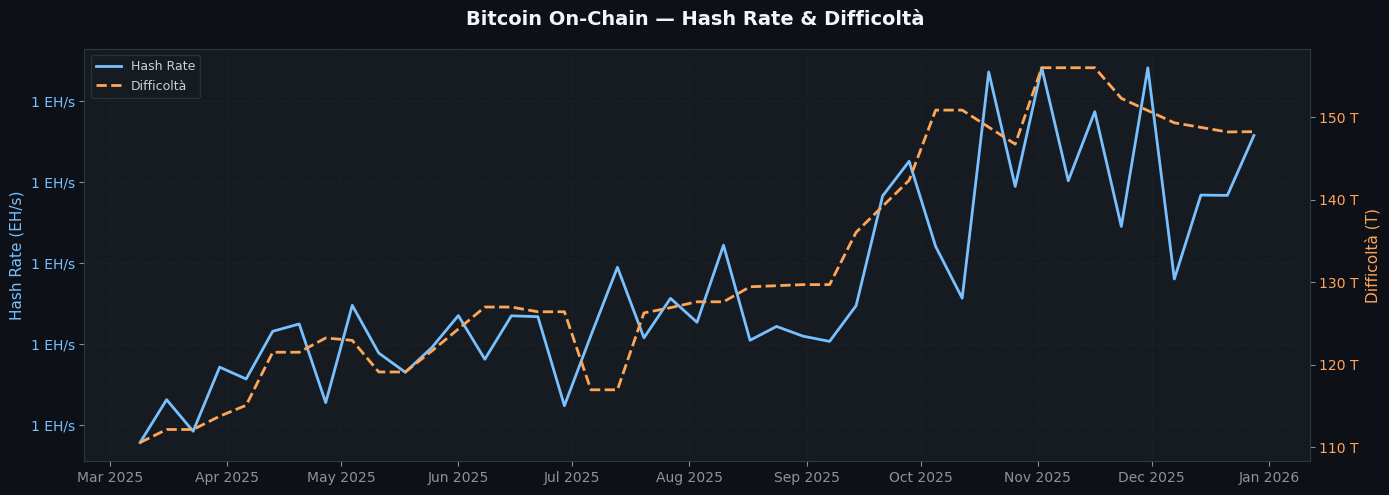

✅ Grafico mining salvato.


In [37]:
fig, ax1 = plt.subplots(figsize=(14, 5))
fig.suptitle('Bitcoin On-Chain — Hash Rate & Difficoltà', fontsize=14, fontweight='bold', color='#f0f6fc')

# Hash Rate (asse sinistro)
color_hr = '#79c0ff'
ax1.set_ylabel('Hash Rate (EH/s)', fontsize=11, color=color_hr)
ax1.plot(df_mining.index, df_mining['hash_rate'] / 1e9,
         color=color_hr, linewidth=2, label='Hash Rate')
ax1.tick_params(axis='y', labelcolor=color_hr)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0f} EH/s'))

# Difficoltà (asse destro)
ax2 = ax1.twinx()
color_diff = '#ffa657'
ax2.set_ylabel('Difficoltà (T)', fontsize=11, color=color_diff)
ax2.plot(df_mining.index, df_mining['difficulty'] / 1e12,
         color=color_diff, linewidth=2, linestyle='--', label='Difficoltà')
ax2.tick_params(axis='y', labelcolor=color_diff)
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0f} T'))

# Legenda combinata
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=9)

ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax1.xaxis.set_major_locator(mdates.MonthLocator())
ax1.grid(True)
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('./data/chart_mining.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Grafico mining salvato.')

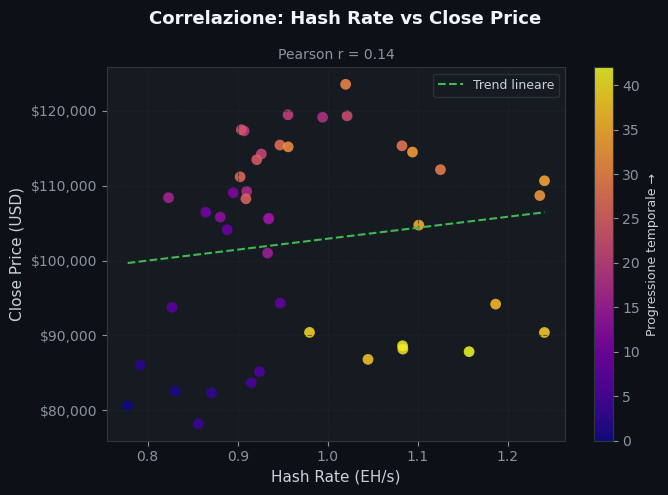

📐 Correlazione Pearson (hash_rate vs Close): 0.136


In [38]:
# Allineamento temporale dei due dataframe
df_combined = df_market[['Close']].join(df_mining[['hash_rate']], how='inner')

fig, ax = plt.subplots(figsize=(7, 5))
fig.suptitle('Correlazione: Hash Rate vs Close Price', fontsize=13, fontweight='bold', color='#f0f6fc')

sc = ax.scatter(df_combined['hash_rate'] / 1e9, df_combined['Close'],
                c=range(len(df_combined)), cmap='plasma',
                s=60, alpha=0.85, edgecolors='none')

# Linea di trend
import numpy as np
z = np.polyfit(df_combined['hash_rate'] / 1e9, df_combined['Close'], 1)
p = np.poly1d(z)
x_line = np.linspace(df_combined['hash_rate'].min() / 1e9,
                     df_combined['hash_rate'].max() / 1e9, 100)
ax.plot(x_line, p(x_line), color='#3fb950', linewidth=1.5,
        linestyle='--', label='Trend lineare')

cbar = plt.colorbar(sc, ax=ax)
cbar.set_label('Progressione temporale →', fontsize=9)

corr = df_combined['hash_rate'].corr(df_combined['Close'])
ax.set_xlabel('Hash Rate (EH/s)', fontsize=11)
ax.set_ylabel('Close Price (USD)', fontsize=11)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.legend(fontsize=9)
ax.set_title(f'Pearson r = {corr:.2f}', fontsize=10, color='#8b949e')
ax.grid(True)
plt.tight_layout()
plt.savefig('./data/chart_correlation.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'📐 Correlazione Pearson (hash_rate vs Close): {corr:.3f}')

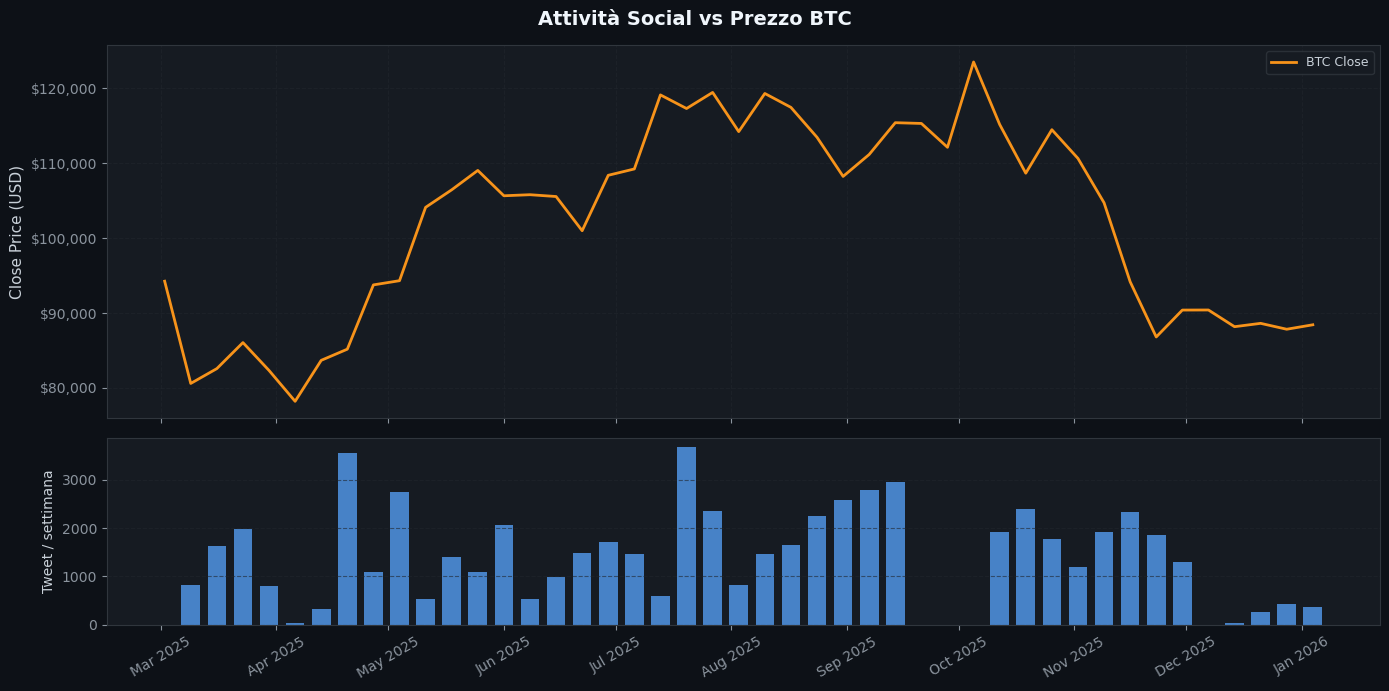

In [39]:
# Aggrega per settimana
df_social_weekly = (
    df_social.set_index('timestamp')
    .resample('W')
    .size()
    .rename('tweet_count')
)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7), sharex=True,
                                gridspec_kw={'height_ratios': [2, 1]})
fig.suptitle('Attività Social vs Prezzo BTC', fontsize=14, fontweight='bold', color='#f0f6fc')

# Close price
ax1.plot(df_market.index, df_market['Close'],
         color='#f7931a', linewidth=2, label='BTC Close')
ax1.set_ylabel('Close Price (USD)', fontsize=11)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax1.legend(fontsize=9)
ax1.grid(True)

# Volume tweet
ax2.bar(df_social_weekly.index, df_social_weekly,
        width=5, color='#58a6ff', alpha=0.75, edgecolor='none')
ax2.set_ylabel('Tweet / settimana', fontsize=10)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax2.xaxis.set_major_locator(mdates.MonthLocator())
ax2.grid(True, axis='y')

plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('./data/chart_social_volume.png', dpi=150, bbox_inches='tight')
plt.show()

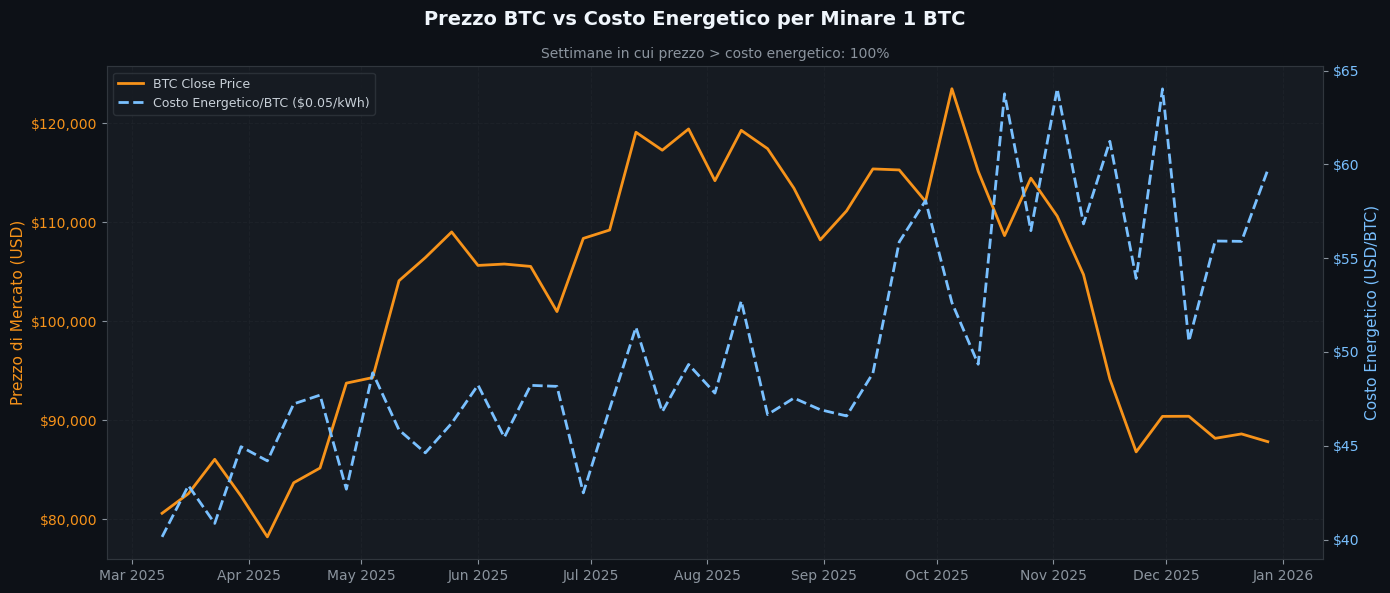

In [20]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np

plt.rcParams.update({
    'figure.facecolor': '#0d1117', 'axes.facecolor': '#161b22',
    'axes.edgecolor': '#30363d', 'axes.labelcolor': '#c9d1d9',
    'xtick.color': '#8b949e', 'ytick.color': '#8b949e',
    'text.color': '#c9d1d9', 'grid.color': '#21262d',
    'grid.linestyle': '--', 'grid.alpha': 0.6,
    'legend.facecolor': '#161b22', 'legend.edgecolor': '#30363d',
})

# Allineamento temporale
df_combo = df_market[['Close']].join(df_energy[['cost_per_btc_usd']], how='inner')

fig, ax1 = plt.subplots(figsize=(14, 6))
fig.suptitle('Prezzo BTC vs Costo Energetico per Minare 1 BTC', fontsize=14, fontweight='bold', color='#f0f6fc')

# Prezzo Close
ax1.plot(df_combo.index, df_combo['Close'], color='#f7931a', linewidth=2, label='BTC Close Price')
ax1.set_ylabel('Prezzo di Mercato (USD)', fontsize=11, color='#f7931a')
ax1.tick_params(axis='y', labelcolor='#f7931a')
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))

# Costo energetico (asse destro)
ax2 = ax1.twinx()
ax2.plot(df_combo.index, df_combo['cost_per_btc_usd'], color='#79c0ff',
         linewidth=2, linestyle='--', label=f'Costo Energetico/BTC (${ELECTRICITY_PRICE_KWH}/kWh)')
ax2.set_ylabel('Costo Energetico (USD/BTC)', fontsize=11, color='#79c0ff')
ax2.tick_params(axis='y', labelcolor='#79c0ff')
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))

# Area: zona "profittevole" (prezzo > costo)
idx = df_combo.index
price = df_combo['Close'].values
cost  = df_combo['cost_per_btc_usd'].values
# Normalizza costo su asse1 per fill_between (solo visivo, non numerico)
# Usiamo invece un'annotazione testuale
profitable_pct = (price > cost).mean() * 100

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=9)

ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax1.xaxis.set_major_locator(mdates.MonthLocator())
ax1.grid(True)
plt.xticks(rotation=30)

ax1.set_title(f'Settimane in cui prezzo > costo energetico: {profitable_pct:.0f}%',
              fontsize=10, color='#8b949e')
plt.tight_layout()
plt.savefig('./data/chart_energy_vs_price.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
from dotenv import load_dotenv
import os
from src.sentiment_engine import SentimentEngine

load_dotenv()

engine = SentimentEngine(api_key=os.getenv("GEMINI_API_KEY"))

df_sentiment = engine.analyze(df_social)
df_sentiment.head()